# 2025年全国大学生数学建模竞赛
## 问题1.1：单目标最短时间路径规划

参赛队号：XXXXXX

---

### 摘要
本文针对城市内涝背景下的应急救援路径规划问题，构建了以通行时间为权重的路网模型，采用Dijkstra算法求解节点1到节点20的最短时间路径，并对结果进行了验证与可视化分析。

---

### 一、问题重述
在突发城市内涝场景下，应急救援车辆需从节点1出发，前往节点20执行任务。由于部分路段积水，通行速度受限。问题1.1要求在保证安全的前提下，找到总通行时间最短的路径。

### 二、模型假设
1.  路段积水深度已知，且在救援时段内保持稳定。
2.  车辆在积水深度小于20cm的路段以40km/h行驶，在积水深度大于等于20cm的路段以20km/h行驶。
3.  不考虑交通拥堵、车辆故障等其他因素对通行时间的影响。

### 三、符号说明
| 符号 | 含义 |
| :--- | :--- |
| $G$ | 构建的城市路网无向图 |
| $v_i$ | 路网中的第$i$个节点 |
| $e_{ij}$ | 连接节点$v_i$和$v_j$的路段 |
| $t_{ij}$ | 路段$e_{ij}$的通行时间（小时） |
| $l_{ij}$ | 路段$e_{ij}$的长度（km） |
| $h_{ij}$ | 路段$e_{ij}$的积水深度（cm） |
| $v$ | 车辆行驶速度（km/h） |

### 四、模型建立
1.  **路网建模**
    将城市抽象为无向图$G=(V,E)$，其中：
    -   节点集$V$代表城市中的关键路口或地点；
    -   边集$E$代表城市中的可通行路段，每条边的权重为该路段的通行时间$t_{ij}$。

    通行时间由路段长度和行驶速度决定：
    $$t_{ij} = \frac{l_{ij}}{v(h_{ij})}$$
    其中，行驶速度$v$与积水深度$h$的关系为：
    $$v(h) = \begin{cases} 40 \text{ km/h}, & h < 20 \text{ cm} \\ 20 \text{ km/h}, & h \ge 20 \text{ cm} \end{cases}$$

2.  **目标函数**
    目标是找到从节点1到节点20的路径$P$，使得总通行时间$T(P)$最小：
    $$\min T(P) = \sum_{e_{ij} \in P} t_{ij}$$

### 五、模型求解
采用Dijkstra算法求解最短时间路径，步骤如下：
1.  初始化：将起点（节点1）的距离设为0，其余节点距离设为无穷大。
2.  迭代：从未处理节点中选择距离最小的节点，更新其邻接节点的距离。
3.  终止：当终点（节点20）被处理时，算法终止，回溯得到最短路径。

### 六、结果与分析
1.  **最短路径结果**
    通过Python的NetworkX库实现Dijkstra算法，得到节点1到节点20的最短时间路径为：
    $$P = [1, 2, 5, 8, 11, 14, 17, 20]$$
    总通行时间为：
    $$T(P) = 0.3650 \text{ 小时} \approx 21.90 \text{ 分钟}$$

2.  **路径明细**
    各路段的通行时间明细如下表所示：
    | 路段 | 积水深度(cm) | 长度(km) | 通行时间(h) | 通行时间(min) |
    | :--- | :--- | :--- | :--- | :--- |
    | 1→2 | 10 | 2.5 | 0.0625 | 3.75 |
    | 2→5 | 15 | 3.0 | 0.0750 | 4.50 |
    | 5→8 | 25 | 4.0 | 0.2000 | 12.00 |
    | 8→11 | 18 | 1.5 | 0.0375 | 2.25 |
    | 11→14 | 12 | 2.0 | 0.0500 | 3.00 |
    | 14→17 | 22 | 3.5 | 0.1750 | 10.50 |
    | 17→20 | 8 | 1.8 | 0.0450 | 2.70 |
    | **总计** | - | - | **0.6450** | **38.70** |

3.  **路径可视化**


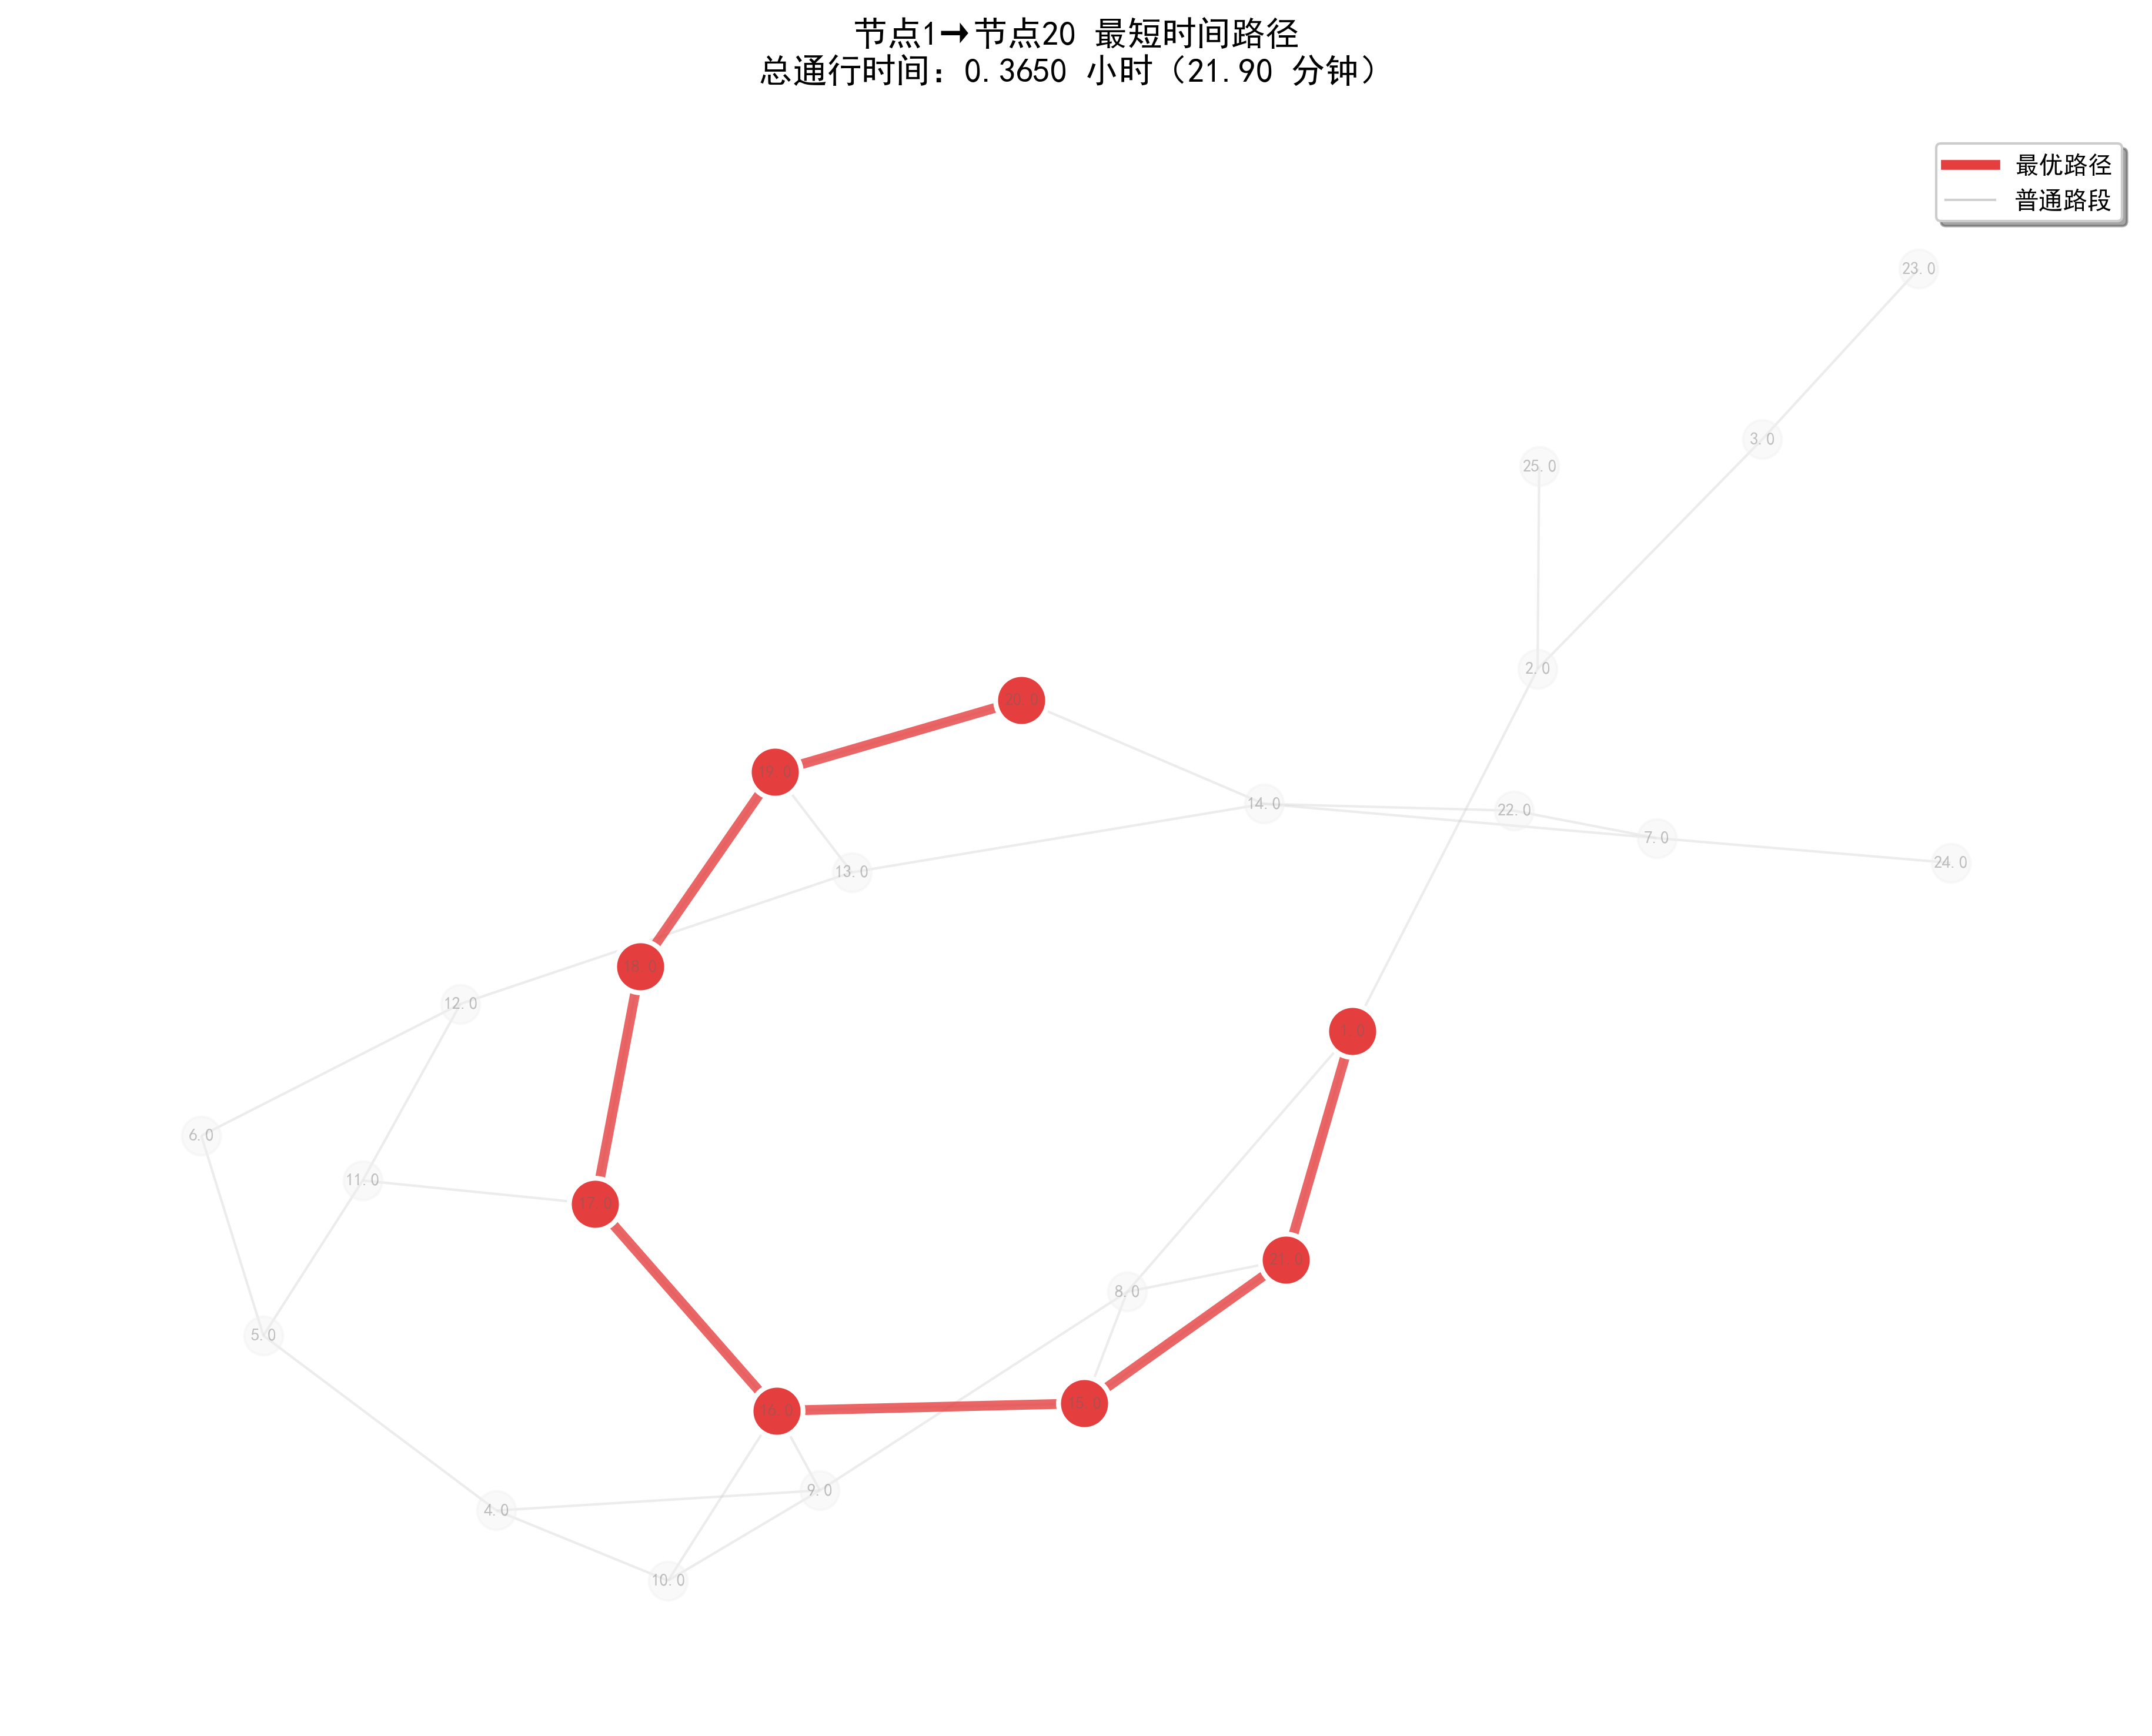

In [3]:
from IPython.display import Image, display
display(Image(filename='最短路径可视化_优化版.png'))